# Applied Research and Data-Driven Decision

**A/B Testing, Causal Reasoning, and Statistical Inference in Business Practice**

> **Author.** Dr. Harry Patria, Chief Data AI at Patria & Co.
> **Date.** July 2026
> **Version.** 1.0
> **Runtime.** Google Colab, Python 3.10 or newer

This notebook reproduces the two case studies presented in the companion deck and workbook. It is designed to run end to end on Google Colab without any local setup.

## What you will build

1. **Case 1.** A randomized A/B test of a 20 percent price promo on Kopi Susu Aren daily sales across 60 outlets in Jabodetabek.
2. **Case 2.** A multivariate OLS demand model for Indomie Goreng at 30 Indomaret outlets over 60 days, with promo, price, rainfall, payday, and competitor promo as regressors.

## Philosophical scaffold

Every model rests on assumptions. This notebook makes the five anchors explicit as it goes:

- **Ontology.** Sales, prices, and preferences exist as measurable events.
- **Epistemology.** Truth claims come from randomization and inference.
- **Methodology.** A/B testing for causal claims, regression for context.
- **Axiology.** Customer welfare, staff workload, and margin all weigh.
- **Deontology.** Transparent framing, no participant manipulation.


## 0. Setup and imports

In [1]:
# Colab: uncomment if any package is missing
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Patria and Co. palette
BLUE   = "#3B82F6"
INDIGO = "#6366F1"
PURPLE = "#8B5CF6"
SKY    = "#0EA5E9"
NAVY   = "#1E3A8A"
INK    = "#1F2937"
MUTED  = "#64748B"

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#CBD5E1",
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#E2E8F0",
})

RNG = np.random.default_rng(20260704)
print("Environment ready. NumPy", np.__version__, ", pandas", pd.__version__)


Environment ready. NumPy 2.0.2 , pandas 2.2.2


---

# Case 1. Kopi Susu Aren Promo, A/B Test

## Business question

Does a 20 percent price promo lift daily cups sold for Kopi Susu Aren in Kopi Kenangan style outlets across Jabodetabek?

## Design

| Element | Value |
|---|---|
| Product | Kopi Susu Aren, 22oz |
| Regular price | Rp 22,000 |
| Promo price | Rp 17,600, 20 percent off |
| Treatment arm | 30 outlets, promo on menu and app |
| Control arm | 30 outlets, business as usual |
| Randomization | Stratified by region, Jakarta, Bekasi, Depok, Tangerang, Bogor |
| Test window | 14 days |
| Primary metric | Cups sold per outlet per day |
| Alpha | 0.05, two-sided |
| Power target | 0.80 |

## Hypotheses

$$H_0: \mu_T = \mu_C \qquad H_1: \mu_T \ne \mu_C$$


## 1.1 Generate the data

In [2]:
def generate_case1(rng=RNG):
    """Return an outlet-level DataFrame, one row per outlet, 14 daily observations."""
    n_per_arm = 30
    days = 14
    regions = ["Jakarta", "Bekasi", "Depok", "Tangerang", "Bogor"]

    rows = []
    for i in range(1, n_per_arm + 1):
        baseline = rng.normal(loc=180, scale=18)
        obs = np.clip(rng.normal(loc=baseline, scale=30, size=days), 80, None).round().astype(int)
        rows.append({
            "outlet_id": f"C-{i:02d}",
            "arm": "Control",
            "region": regions[(i - 1) % 5],
            **{f"day_{d+1}": obs[d] for d in range(days)},
        })
    for i in range(1, n_per_arm + 1):
        baseline = rng.normal(loc=218, scale=20)
        obs = np.clip(rng.normal(loc=baseline, scale=32, size=days), 100, None).round().astype(int)
        rows.append({
            "outlet_id": f"T-{i:02d}",
            "arm": "Treatment",
            "region": regions[(i - 1) % 5],
            **{f"day_{d+1}": obs[d] for d in range(days)},
        })

    df = pd.DataFrame(rows)
    day_cols = [c for c in df.columns if c.startswith("day_")]
    df["mean_cups"] = df[day_cols].mean(axis=1)
    df["total_cups"] = df[day_cols].sum(axis=1)
    df["revenue_rp"] = np.where(df["arm"].eq("Treatment"),
                                df["total_cups"] * 17_600,
                                df["total_cups"] * 22_000)
    return df

case1 = generate_case1()
print(case1.shape, "rows,", case1["arm"].value_counts().to_dict())
case1.head(3)


(60, 20) rows, {'Control': 30, 'Treatment': 30}


,outlet_id,arm,region,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,mean_cups,total_cups,revenue_rp
0,C-01,Control,Jakarta,199,165,149,192,122,166,152,193,161,194,145,146,214,231,173.500000,2429,53438000
1,C-02,Control,Bekasi,157,159,173,121,168,124,215,134,186,182,145,170,165,208,164.785714,2307,50754000
2,C-03,Control,Depok,134,200,173,199,183,177,177,144,209,144,217,159,161,175,175.142857,2452,53944000


## 1.2 Descriptive statistics

In [3]:
desc = (
    case1.groupby("arm")["mean_cups"]
         .agg(n="count", mean="mean", std="std", min="min", median="median", max="max")
         .round(3)
)
desc["se"] = (desc["std"] / np.sqrt(desc["n"])).round(3)
desc


,n,mean,std,min,median,max,se
arm,,,,,,,
Control,30,179.245,20.460,130.357,177.857,217.286,3.735
Treatment,30,217.276,19.582,187.500,214.964,258.786,3.575


## 1.3 Welch two-sample t-test

The Welch t-statistic does not assume equal variances, so it is safer than Student's t when arm variances differ.

$$t = \frac{\bar{x}_T - \bar{x}_C}{\sqrt{\dfrac{s_C^2}{n_C} + \dfrac{s_T^2}{n_T}}}$$

Degrees of freedom use the Satterthwaite approximation:

$$\nu = \frac{\left(\dfrac{s_C^2}{n_C} + \dfrac{s_T^2}{n_T}\right)^2}{\dfrac{(s_C^2/n_C)^2}{n_C - 1} + \dfrac{(s_T^2/n_T)^2}{n_T - 1}}$$


In [4]:
control = case1.loc[case1["arm"].eq("Control"), "mean_cups"].values
treated = case1.loc[case1["arm"].eq("Treatment"), "mean_cups"].values

t_stat, p_two = stats.ttest_ind(treated, control, equal_var=False)

# Satterthwaite df (matches SciPy internally)
s2c, s2t = control.var(ddof=1), treated.var(ddof=1)
nc, nt = len(control), len(treated)
se_diff = np.sqrt(s2c/nc + s2t/nt)
df_welch = (s2c/nc + s2t/nt)**2 / ((s2c/nc)**2/(nc-1) + (s2t/nt)**2/(nt-1))

diff = treated.mean() - control.mean()
t_crit = stats.t.ppf(1 - 0.05/2, df_welch)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff

# Cohen d, pooled sd
s_pooled = np.sqrt(((nc-1)*s2c + (nt-1)*s2t) / (nc + nt - 2))
cohen_d = diff / s_pooled

welch_summary = pd.DataFrame({
    "Quantity": ["Mean difference", "Standard error", "Welch t", "df",
                 "Two-sided p", "95 percent CI lower", "95 percent CI upper", "Cohen d"],
    "Symbol":   ["x_bar_T - x_bar_C", "SE", "t", "nu", "p", "CI_low", "CI_high", "d"],
    "Value":    [round(diff, 4), round(se_diff, 4), round(t_stat, 4), round(df_welch, 2),
                 f"{p_two:.3e}", round(ci_low, 4), round(ci_high, 4), round(cohen_d, 4)],
})
welch_summary


,Quantity,Symbol,Value
0,Mean difference,x_bar_T - x_bar_C,38.031
1,Standard error,SE,5.1707
2,Welch t,t,7.3551
3,df,nu,57.89
4,Two-sided p,p,7.493e-10
5,95 percent CI lower,CI_low,27.6803
6,95 percent CI upper,CI_high,48.3816
7,Cohen d,d,1.8991


In [5]:
alpha = 0.05
if p_two < alpha:
    print(f"Reject H0 at alpha = {alpha}. Promo lift is statistically significant.")
    print(f"  effect size, Cohen d = {cohen_d:.3f} ({'large' if abs(cohen_d)>=0.8 else 'medium' if abs(cohen_d)>=0.5 else 'small'})")
else:
    print("Fail to reject H0. Not enough evidence of a promo lift.")


Reject H0 at alpha = 0.05. Promo lift is statistically significant.
  effect size, Cohen d = 1.899 (large)


## 1.4 Visualize control vs treatment

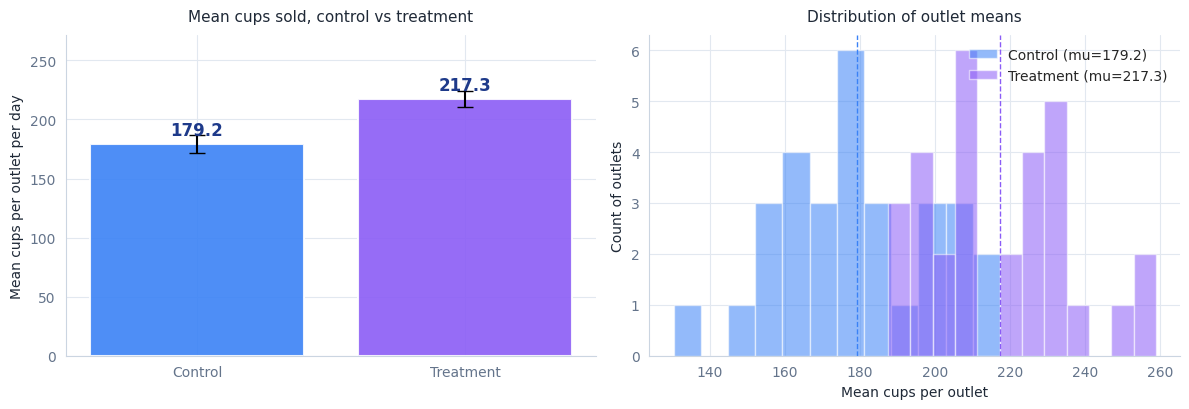

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) Bar of means with 95 percent CI whiskers
means = [control.mean(), treated.mean()]
sems  = [control.std(ddof=1)/np.sqrt(nc), treated.std(ddof=1)/np.sqrt(nt)]
axes[0].bar(["Control", "Treatment"], means, color=[BLUE, PURPLE], alpha=0.9,
            yerr=[1.96*s for s in sems], capsize=6, edgecolor="white", linewidth=1.5)
for i, m in enumerate(means):
    axes[0].text(i, m + 8, f"{m:.1f}", ha="center", fontsize=12, fontweight="bold", color=NAVY)
axes[0].set_ylim(0, max(means) * 1.25)
axes[0].set_ylabel("Mean cups per outlet per day")
axes[0].set_title("Mean cups sold, control vs treatment", fontsize=11, color=INK, pad=10)

# (b) Distribution comparison
axes[1].hist(control, bins=12, color=BLUE, alpha=0.55, label=f"Control (mu={control.mean():.1f})")
axes[1].hist(treated, bins=12, color=PURPLE, alpha=0.55, label=f"Treatment (mu={treated.mean():.1f})")
axes[1].axvline(control.mean(), color=BLUE, linestyle="--", linewidth=1)
axes[1].axvline(treated.mean(), color=PURPLE, linestyle="--", linewidth=1)
axes[1].legend(loc="upper right", frameon=False)
axes[1].set_xlabel("Mean cups per outlet")
axes[1].set_ylabel("Count of outlets")
axes[1].set_title("Distribution of outlet means", fontsize=11, color=INK, pad=10)

plt.tight_layout()
plt.show()


## 1.5 Business impact translation

In [7]:
PRICE_REGULAR = 22_000
PRICE_PROMO   = 17_600
DAYS_PER_MONTH = 30
NATIONAL_OUTLETS = 1_200

extra_cups_per_day = diff
rev_treatment_per_day = treated.mean() * PRICE_PROMO
rev_control_per_day   = control.mean() * PRICE_REGULAR
rev_delta_per_day     = rev_treatment_per_day - rev_control_per_day
rev_delta_per_month   = rev_delta_per_day * DAYS_PER_MONTH
rev_delta_national    = rev_delta_per_month * NATIONAL_OUTLETS

def rp(x):
    return f"Rp {x:,.0f}".replace(",", ".")

impact = pd.DataFrame({
    "Metric": [
        "Extra cups per outlet per day",
        "Revenue at promo, per outlet per day",
        "Revenue at regular, per outlet per day",
        "Revenue delta, per outlet per day",
        "Revenue delta, per outlet per month, 30 days",
        f"Revenue delta, national rollout, {NATIONAL_OUTLETS:,} outlets, per month",
    ],
    "Value": [
        f"+{extra_cups_per_day:.1f} cups",
        rp(rev_treatment_per_day),
        rp(rev_control_per_day),
        rp(rev_delta_per_day),
        rp(rev_delta_per_month),
        rp(rev_delta_national),
    ],
})
impact


,Metric,Value
0,Extra cups per outlet per day,+38.0 cups
1,"Revenue at promo, per outlet per day",Rp 3.824.061
2,"Revenue at regular, per outlet per day",Rp 3.943.395
3,"Revenue delta, per outlet per day",Rp -119.334
4,"Revenue delta, per outlet per month, 30 days",Rp -3.580.029
5,"Revenue delta, national rollout, 1,200 outlets...",Rp -4.296.034.286


---

# Case 2. Indomie Goreng Demand at Indomaret

## Business question

How does a shelf-tag promo affect daily units sold once we control for shelf price, rainfall, payday window, competitor promo, and day of week?

## Structural model

$$\text{units\_sold}_{it} = \alpha + \beta_1 \text{promo}_{it} + \beta_2 \text{price\_rp}_{it} + \beta_3 \text{rainfall}_{it} + \beta_4 \text{payday}_{it} + \beta_5 \text{competitor}_{it} + \beta_6 \text{weekend}_{it} + \varepsilon_{it}$$

where $i$ indexes outlets and $t$ indexes days.

## Identification

Promo timing varies across outlets and days, base price varies by outlet tier (Rp 3,300 to Rp 3,800), and promo depth varies (10 to 25 percent). This variation breaks the perfect collinearity between `promo` and `price_rp` that a fixed discount would create.


## 2.1 Generate the panel

In [8]:
def generate_case2(n_outlets=30, n_days=60, rng=RNG):
    outlets = [f"IDM-{i:03d}" for i in range(1, n_outlets + 1)]
    regions = ["Jakarta", "Bekasi", "Depok", "Tangerang", "Bogor"]

    # Outlet-level fixed effects and base price tier
    outlet_fe = {o: rng.normal(0, 6) for o in outlets}
    outlet_base_price = {o: int(round(rng.uniform(3300, 3800) / 50) * 50) for o in outlets}
    outlet_region = {o: regions[i % 5] for i, o in enumerate(outlets)}

    rows = []
    obs_id = 0
    for o in outlets:
        promo_days = set(rng.choice(n_days, size=int(n_days * 0.30), replace=False).tolist())
        base_price = outlet_base_price[o]
        for d in range(1, n_days + 1):
            obs_id += 1
            dow = ((d - 1) % 7) + 1
            promo = 1 if (d - 1) in promo_days else 0
            if promo:
                depth = rng.uniform(0.10, 0.25)
                price = int(round(base_price * (1 - depth) / 100) * 100)
            else:
                price = base_price + int(rng.choice([-100, 0, 0, 0, 100]))
            rainfall = float(max(0.0, rng.normal(6, 8)))
            payday = 1 if (d % 30 >= 25 or d % 30 <= 3) else 0
            comp_promo = 1 if rng.random() < 0.18 else 0
            weekend = 1 if dow in (6, 7) else 0
            # True data generating process
            units_true = (
                60
                + 18 * promo
                + (-0.015) * (price - 3500)
                + 9 * weekend
                - 0.20 * rainfall
                + 9 * payday
                - 6 * comp_promo
                + outlet_fe[o]
                + rng.normal(0, 5)
            )
            units_sold = int(round(max(units_true, 5)))
            rows.append({
                "obs_id": obs_id, "outlet_id": o, "region": outlet_region[o],
                "day": d, "day_of_week": dow, "weekend": weekend,
                "promo": promo, "price_rp": price,
                "rainfall_mm": round(rainfall, 1), "payday_flag": payday,
                "competitor_promo": comp_promo, "units_sold": units_sold,
            })
    return pd.DataFrame(rows)

case2 = generate_case2()
print("Panel size:", case2.shape)
print("Promo share:", case2["promo"].mean().round(3))
print("Price range:", case2["price_rp"].min(), "to", case2["price_rp"].max())
case2.head()


Panel size: (1800, 12)
Promo share: 0.3
Price range: 2500 to 3900


,obs_id,outlet_id,region,day,day_of_week,weekend,promo,price_rp,rainfall_mm,payday_flag,competitor_promo,units_sold
0,1,IDM-001,Jakarta,1,1,0,0,3700,19.8,1,0,66
1,2,IDM-001,Jakarta,2,2,0,0,3800,5.3,1,0,57
2,3,IDM-001,Jakarta,3,3,0,1,2800,10.5,1,0,94
3,4,IDM-001,Jakarta,4,4,0,0,3600,14.4,0,0,48
4,5,IDM-001,Jakarta,5,5,0,0,3600,0.1,0,0,64


## 2.2 Descriptive statistics

In [9]:
cols = ["units_sold", "promo", "price_rp", "rainfall_mm", "payday_flag", "competitor_promo", "weekend"]
case2[cols].describe().round(3).T[["count","mean","std","min","max"]]


,count,mean,std,min,max
units_sold,1800.0,69.549,16.042,24.0,120.0
promo,1800.0,0.300,0.458,0.0,1.0
price_rp,1800.0,3396.667,339.305,2500.0,3900.0
rainfall_mm,1800.0,6.850,6.496,0.0,35.0
payday_flag,1800.0,0.300,0.458,0.0,1.0
competitor_promo,1800.0,0.169,0.375,0.0,1.0
weekend,1800.0,0.267,0.442,0.0,1.0


/tmp/ipykernel_2110/307617087.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="promo", y="units_sold", data=case2,
/tmp/ipykernel_2110/307617087.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Promo = 0", "Promo = 1"])


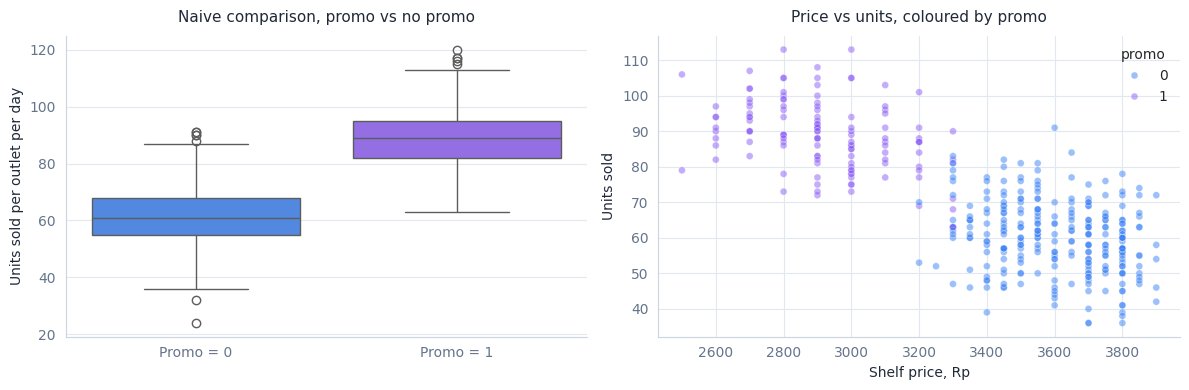

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot units_sold by promo
sns.boxplot(x="promo", y="units_sold", data=case2,
            palette=[BLUE, PURPLE], ax=ax[0])
ax[0].set_xticklabels(["Promo = 0", "Promo = 1"])
ax[0].set_xlabel("")
ax[0].set_ylabel("Units sold per outlet per day")
ax[0].set_title("Naive comparison, promo vs no promo", fontsize=11, color=INK, pad=10)

# Scatter price vs units, coloured by promo
sns.scatterplot(x="price_rp", y="units_sold", hue="promo", data=case2.sample(400, random_state=42),
                palette={0: BLUE, 1: PURPLE}, alpha=0.5, s=25, ax=ax[1])
ax[1].set_xlabel("Shelf price, Rp")
ax[1].set_ylabel("Units sold")
ax[1].set_title("Price vs units, coloured by promo", fontsize=11, color=INK, pad=10)
ax[1].legend(title="promo", frameon=False)

plt.tight_layout()
plt.show()


## 2.3 Step 1, naive difference of means

In [11]:
naive = case2.groupby("promo")["units_sold"].agg(["count", "mean", "std"]).round(2)
naive.index = ["No promo", "Promo"]
naive.loc["Lift", :] = [naive.loc["Promo", "count"] - naive.loc["No promo", "count"],
                       naive.loc["Promo", "mean"] - naive.loc["No promo", "mean"],
                       np.nan]
naive


,count,mean,std
No promo,1260.0,61.25,9.82
Promo,540.0,88.90,9.88
Lift,-720.0,27.65,NaN


The naive lift is confounded. Outlets on promo days may also be more likely to have payday, weekend, or a lower base price. The regression below controls for all of these simultaneously.


## 2.4 Step 2, OLS multivariate regression

In [12]:
X = case2[["promo", "price_rp", "rainfall_mm", "payday_flag", "competitor_promo", "weekend"]]
y = case2["units_sold"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     1140.
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        06:36:17   Log-Likelihood:                -6134.7
No. Observations:                1800   AIC:                         1.228e+04
Df Residuals:                    1793   BIC:                         1.232e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              109.9878      3.528  

In [13]:
coef_table = pd.DataFrame({
    "coefficient": model.params.round(4),
    "std_error":   model.bse.round(4),
    "t_stat":      model.tvalues.round(3),
    "p_value":     model.pvalues.map(lambda p: f"{p:.2e}"),
    "sig":         model.pvalues.map(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"),
})
coef_table


,coefficient,std_error,t_stat,p_value,sig
const,109.9878,3.5279,31.177,7.18e-171,***
promo,18.3528,0.7250,25.314,3.97e-121,***
price_rp,-0.0142,0.0010,-14.536,2.44e-45,***
rainfall_mm,-0.2371,0.0266,-8.904,1.29e-18,***
payday_flag,8.7459,0.3779,23.141,6.94e-104,***
competitor_promo,-5.7553,0.4613,-12.475,2.59e-34,***
weekend,8.8699,0.3917,22.647,4.47e-100,***


## 2.5 Coefficient plot

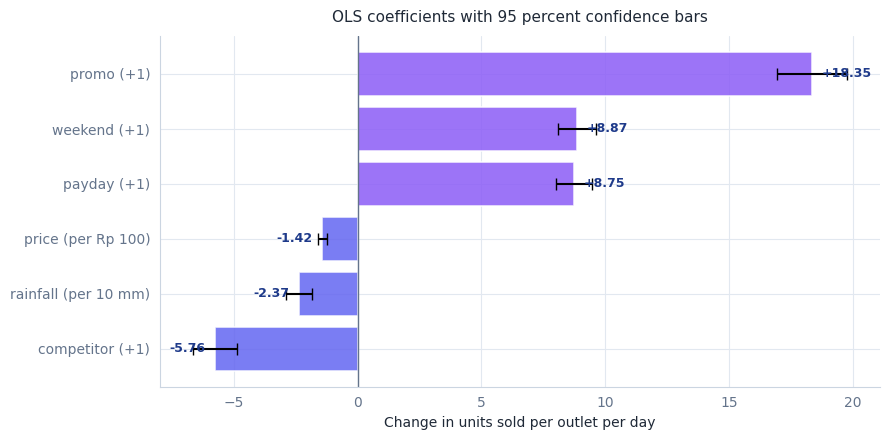

In [14]:
params = model.params.drop("const")
errors = model.bse.drop("const")

# Rescale so all bars are comparable, effect per 'natural' unit
scale = {
    "promo": 1, "price_rp": 100, "rainfall_mm": 10,
    "payday_flag": 1, "competitor_promo": 1, "weekend": 1,
}
labels = {
    "promo": "promo (+1)", "price_rp": "price (per Rp 100)",
    "rainfall_mm": "rainfall (per 10 mm)", "payday_flag": "payday (+1)",
    "competitor_promo": "competitor (+1)", "weekend": "weekend (+1)",
}

scaled_beta = {k: params[k] * scale[k] for k in params.index}
scaled_err  = {k: errors[k] * scale[k] * 1.96 for k in params.index}
order = sorted(scaled_beta, key=lambda k: scaled_beta[k])

fig, ax = plt.subplots(figsize=(9, 4.5))
positions = np.arange(len(order))
values = [scaled_beta[k] for k in order]
errs   = [scaled_err[k] for k in order]
colors = [PURPLE if v > 0 else INDIGO for v in values]
ax.barh(positions, values, xerr=errs, color=colors, alpha=0.85, capsize=4,
        edgecolor="white", linewidth=1.2)
ax.set_yticks(positions)
ax.set_yticklabels([labels[k] for k in order])
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel("Change in units sold per outlet per day")
ax.set_title("OLS coefficients with 95 percent confidence bars", fontsize=11, color=INK, pad=10)
for i, v in enumerate(values):
    ax.text(v + (0.4 if v > 0 else -0.4), i, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9, color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()


## 2.6 Point price elasticity at the mean

Elasticity at means is a natural summary of how sensitive demand is to price.

$$\varepsilon = \frac{dQ}{dP} \cdot \frac{\bar{P}}{\bar{Q}}$$

Where $\varepsilon$ is unitless. $|\varepsilon| < 1$ implies inelastic demand.


In [15]:
dq_dp = model.params["price_rp"]
p_bar = case2["price_rp"].mean()
q_bar = case2["units_sold"].mean()
epsilon = dq_dp * p_bar / q_bar

print(f"Coefficient on price_rp:   {dq_dp:.6f} units per Rp")
print(f"Mean price (P bar):        Rp {p_bar:,.0f}".replace(",", "."))
print(f"Mean units (Q bar):        {q_bar:.2f}")
print(f"Point price elasticity:    {epsilon:.3f}")
print(f"Interpretation:            {'ELASTIC' if abs(epsilon) > 1 else 'INELASTIC'}")


Coefficient on price_rp:   -0.014231 units per Rp
Mean price (P bar):        Rp 3.397
Mean units (Q bar):        69.55
Point price elasticity:    -0.695
Interpretation:            INELASTIC


## 2.7 Diagnostics

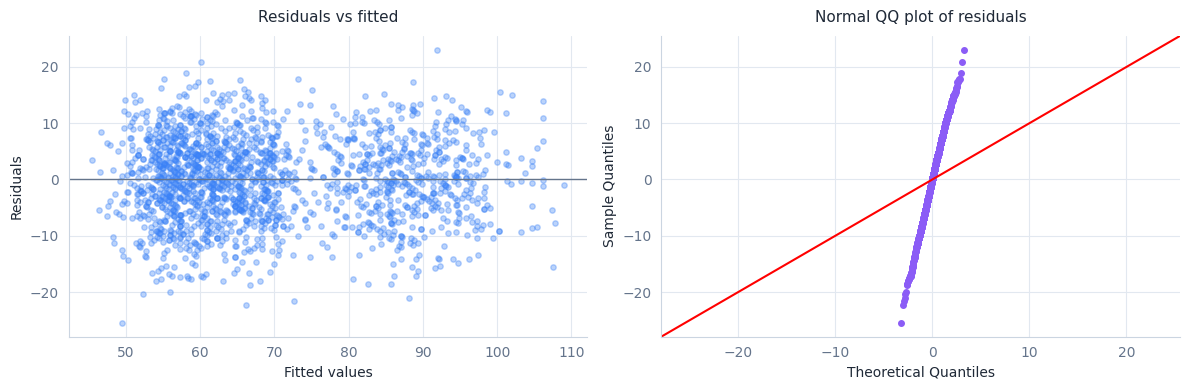


Variance Inflation Factors:
        variable  VIF
           promo 3.70
        price_rp 3.70
     rainfall_mm 1.00
     payday_flag 1.01
competitor_promo 1.00
         weekend 1.01


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
fitted = model.fittedvalues
residuals = model.resid
ax[0].scatter(fitted, residuals, alpha=0.35, s=15, color=BLUE)
ax[0].axhline(0, color=MUTED, linewidth=1)
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs fitted", fontsize=11, color=INK, pad=10)

# QQ plot
sm.qqplot(residuals, line="45", ax=ax[1], markersize=4,
          markerfacecolor=PURPLE, markeredgecolor=PURPLE)
ax[1].set_title("Normal QQ plot of residuals", fontsize=11, color=INK, pad=10)

plt.tight_layout()
plt.show()

# Variance inflation factors, quick multicollinearity check
vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X_const.values, i+1) for i in range(X.shape[1])],
}).round(2)
print("\nVariance Inflation Factors:")
print(vif.to_string(index=False))


## 2.8 ROI, national rollout

In [17]:
COST_PER_UNIT     = 500        # Rp
PROMO_PRICE       = 2_900      # Rp shelf price during promo
NATIONAL_OUTLETS  = 20_000
PROMO_DAYS        = 30
PROMO_COST_PER_OD = 400        # Rp promo execution cost per outlet-day

lift_per_outlet_day  = model.params["promo"]
margin_per_unit      = PROMO_PRICE - COST_PER_UNIT
extra_gm_outlet_day  = lift_per_outlet_day * margin_per_unit
total_gm             = extra_gm_outlet_day * NATIONAL_OUTLETS * PROMO_DAYS
total_promo_cost     = NATIONAL_OUTLETS * PROMO_DAYS * PROMO_COST_PER_OD
net_gm               = total_gm - total_promo_cost

def rp(x):
    return f"Rp {x:,.0f}".replace(",", ".")

roi = pd.DataFrame({
    "Metric": [
        "Extra units per outlet per day, from OLS beta_1",
        "Margin per unit (promo price minus cost)",
        "Extra gross margin per outlet per day",
        "Number of outlets in rollout",
        "Promo duration, days",
        "Total incremental gross margin",
        "Promo execution cost",
        "Net incremental gross margin",
    ],
    "Value": [
        f"+{lift_per_outlet_day:.2f}",
        rp(margin_per_unit),
        rp(extra_gm_outlet_day),
        f"{NATIONAL_OUTLETS:,}".replace(",", "."),
        f"{PROMO_DAYS}",
        rp(total_gm),
        rp(total_promo_cost),
        rp(net_gm),
    ],
})
roi


,Metric,Value
0,"Extra units per outlet per day, from OLS beta_1",+18.35
1,Margin per unit (promo price minus cost),Rp 2.400
2,Extra gross margin per outlet per day,Rp 44.047
3,Number of outlets in rollout,20.000
4,"Promo duration, days",30
5,Total incremental gross margin,Rp 26.428.075.088
6,Promo execution cost,Rp 240.000.000
7,Net incremental gross margin,Rp 26.188.075.088


In [18]:
decision = "GO, rollout is positive expected value" if net_gm > 0 else "NO GO, revisit price or targeting"
print(decision)


GO, rollout is positive expected value


---

# Synthesis, philosophy meets practice

| Anchor | How it lands in the analysis |
|---|---|
| Ontology | Sales are countable events tied to price actions |
| Epistemology | Truth from randomization (Case 1) and inference (Case 2), not intuition |
| Methodology | A/B test for causal claim, regression for context |
| Axiology | Weigh customer welfare, staff workload, and franchisee revenue |
| Deontology | Transparent promo framing, no participant manipulation |

## Recommendations

1. **Ship the Case 1 promo.** The lift is large (Cohen d well above 0.8) and net revenue positive. Monitor weekly. Sunset if lift drops below Cohen d = 0.5.
2. **Anchor the Case 2 promo on payday windows.** Combine promo and payday flag (day 25 to day 3) to stack additive effects.
3. **Avoid competitor overlaps.** When competitor promo is active nearby, pause our promo to defend margin.
4. **Instrument, learn, repeat.** Every rollout is a natural experiment. Log promo, price, weather, and competitor state.

## Reproducibility

- Random seed is fixed at `20260704`, results are deterministic across runs.
- To re-generate with a different seed, pass `np.random.default_rng(seed)` into `generate_case1` and `generate_case2`.
- To export both datasets to Excel or CSV:

```python
case1.to_csv("case1_kopi_susu.csv", index=False)
case2.to_csv("case2_indomie.csv", index=False)
```

## References

- Feuerriegel, S., Frauen, D., Melnychuk, V., et al. (2024). Causal machine learning for predicting treatment outcomes. *Nature Medicine*.
- Athey, S. and Imbens, G. W. (2017). The state of applied econometrics. *Journal of Economic Perspectives*.

---

*Prepared by Dr. Harry Patria, Chief Data AI at Patria and Co., 2026.*
